#**Projeto Chronos**
##CHALLENGE LOCAWEB 2026
Integrantes:

* Bruno Rosa - RM563779
* Danilo Alves - RM564109
* Enzo Cremaschi - RM562058
* Vinícius Macedo - RM561911

# EDA Complementar — Locaweb Challenge 2026 (Projeto Cronos)
### Aprofundamento das hipóteses estatísticas levantadas na primeira rodada de EDA

Este notebook parte dos achados já confirmados (nulidade explicada por `Aberto por`, série não-estacionária mesmo em 2025, `Grupo designado` como variável mais associada ao risco, padrão contra-intuitivo de `Duração` por Prioridade) e investiga **por quê** cada um acontece, com testes estatísticos formais. O objetivo é tomar decisões de engenharia de features já validadas, não apenas hipóteses.

**Estrutura:**
1. Exclusão formal de 2023-2024 (teste de que não é sinal, é ruído)
2. `Duração` como mistura de populações — decompor por modo de fechamento (`Status`)
3. Estacionariedade — diferenciação de 1ª ordem e novo teste ADF/KPSS
4. `Grupo designado` a fundo — é sinal real ou confundido com volume/Prioridade?
5. `Status` dentro do universo elegível para KPI — o "zero" de associação é real?
6. Redundância entre texto e variáveis estruturadas
7. Caracterização dos outliers extremos de `Duração`
8. Dispersão do volume semanal de violações (Poisson vs. sobre-dispersão)
9. Investigação dos 32 casos de `Resolvido > Encerrado`
10. Síntese — decisões atualizadas para a Arquitetura Medalhão


## Setup e carga

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, kruskal
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

df = pd.read_excel('/content/drive/MyDrive/LW-DATASET.xlsx')
df['data'] = df['Aberto'].dt.date
print(f'Shape: {df.shape[0]:,} linhas'.replace(',', '.'))


Mounted at /content/drive
Shape: 122.543 linhas


## 1. 2023-2024: ruído residual ou sinal real?

Na EDA anterior, o volume total desses dois anos somou 732 chamados (0,6% da base). Antes de simplesmente excluir, vale checar se esses registros têm alguma característica sistematicamente diferente de 2025 — isso ajuda a decidir entre "excluir sem receio" e "investigar antes de excluir".

In [ ]:
df['ano'] = df['Aberto'].dt.year
pre_2025 = df[df['ano'].isin([2023, 2024])]
pos_2025 = df[df['ano'] == 2025]

print(f'Registros 2023-2024: {len(pre_2025)} ({len(pre_2025)/len(df)*100:.2f}% da base)')
print(f'Registros 2025: {len(pos_2025)} ({len(pos_2025)/len(df)*100:.2f}% da base)')

Registros 2023-2024: 732 (0.60% da base)
Registros 2025: 121811 (99.40% da base)


In [ ]:
# Esses registros têm o mesmo perfil de Aberto por / Prioridade / Grupo designado que 2025,
# ou parecem dados de teste/carga inicial do sistema?
for col in ['Aberto por', 'Prioridade', 'Status']:
    print(f'--- {col} ---')
    comp = pd.DataFrame({
        '2023-2024 (%)': pre_2025[col].value_counts(normalize=True).round(3) * 100,
        '2025 (%)': pos_2025[col].value_counts(normalize=True).round(3) * 100,
    })
    display(comp)
    print()

--- Aberto por ---


,2023-2024 (%),2025 (%)
Aberto por,,
Manual,73.6,14.5
Monitoramento,26.4,85.5



--- Prioridade ---


,2023-2024 (%),2025 (%)
Prioridade,,
1 - Crítica,NaN,0.0
2 - Alta,0.5,12.8
3 - Média,64.5,33.9
4 - Baixa,33.9,53.0
5 - Muito Baixa,1.1,0.3



--- Status ---


,2023-2024 (%),2025 (%)
Status,,
Aguardando Problema,NaN,0.0
Encerrado,10.0,12.5
Encerrado Automaticamente,89.6,21.5
Sem Intervenção,0.4,66.0


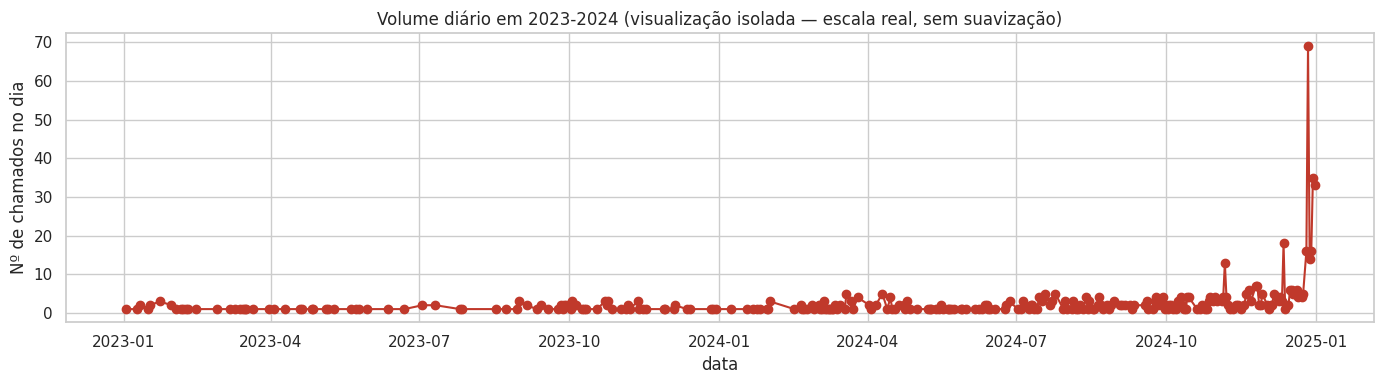

In [ ]:
fig, ax = plt.subplots(figsize=(14, 4))
pre_2025.groupby('data').size().plot(ax=ax, marker='o', linestyle='-', color='#c0392b')
ax.set_title('Volume diário em 2023-2024 (visualização isolada — escala real, sem suavização)')
ax.set_ylabel('Nº de chamados no dia')
plt.tight_layout()
plt.show()

## 2. `Duração` como mistura de populações — decompor por `Status`

O achado da EDA anterior (mediana de Duração muito mais alta em "Muito Baixa" do que em "Baixa") é contra-intuitivo até cruzarmos com o modo de fechamento. A hipótese aqui é que `Duração` não é uma variável única — é a mistura de 3 processos diferentes: fechamento sem intervenção (rápido), fechamento automático por timeout (lento) e fechamento humano (intermediário).

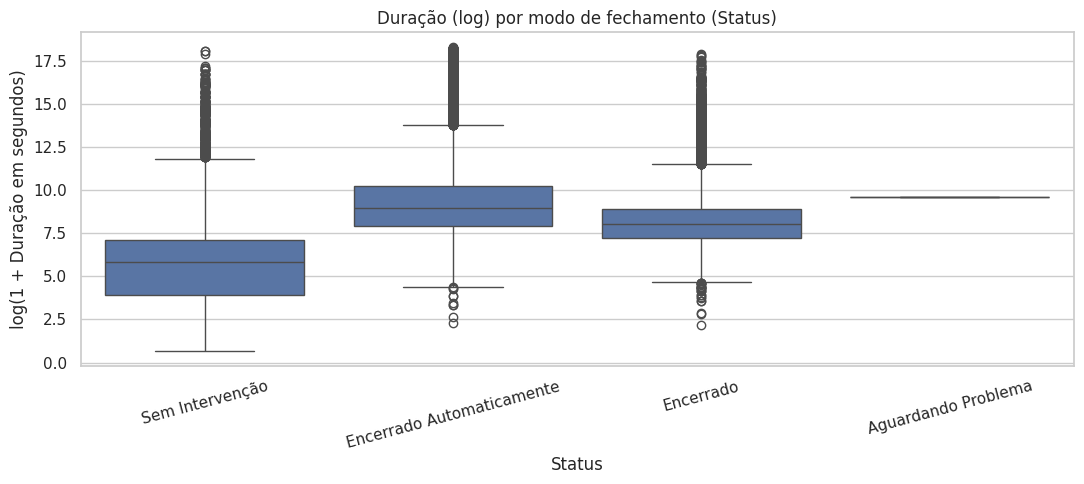

,Duração
Status,
Aguardando Problema,14537.0
Encerrado Automaticamente,7873.0
Encerrado,3144.0
Sem Intervenção,334.0


In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
ordem_status = df['Status'].value_counts().index
sns.boxplot(data=df, x='Status', y=np.log1p(df['Duração']), order=ordem_status, ax=ax)
ax.set_ylabel('log(1 + Duração em segundos)') # por isso aplicado o log1
ax.set_title('Duração (log) por modo de fechamento (Status)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

display(df.groupby('Status')['Duração'].median().sort_values(ascending=False))

In [ ]:
# Teste de Kruskal-Wallis: as distribuições de Duração diferem significativamente entre os Status?
grupos_status = [df[df['Status'] == s]['Duração'].values for s in df['Status'].unique()]
h_stat, p_valor = kruskal(*grupos_status)
print(f'Kruskal-Wallis H: {h_stat:.2f}, p-valor: {p_valor:.2e}')
print('Conclusão:', 'distribuições diferem significativamente por Status' if p_valor < 0.05 else 'sem diferença significativa')

Kruskal-Wallis H: 50053.42, p-valor: 0.00e+00
Conclusão: distribuições diferem significativamente por Status


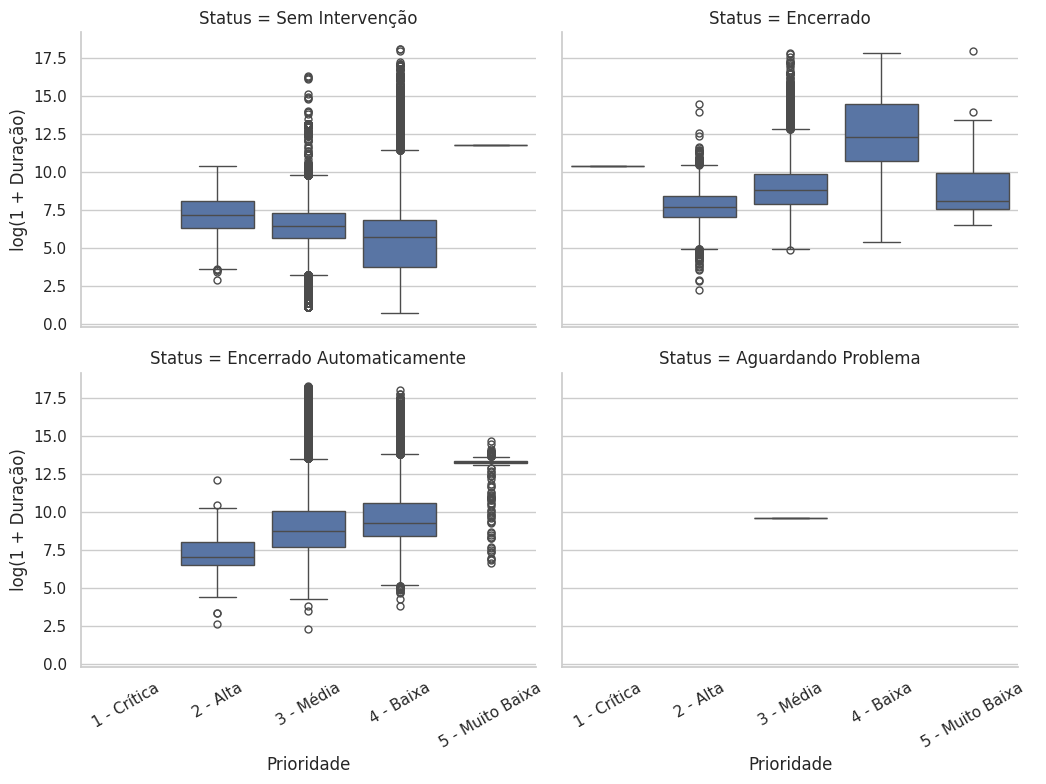

In [ ]:
# Repetir a comparação de Duração por Prioridade, agora DENTRO de cada Status
# (controla o confundimento identificado na EDA anterior)
g = sns.catplot(
    data=df, x='Prioridade', y=np.log1p(df['Duração']), col='Status',
    kind='box', col_wrap=2, height=4, aspect=1.3,
    order=['1 - Crítica', '2 - Alta', '3 - Média', '4 - Baixa', '5 - Muito Baixa']
)
g.set_axis_labels('Prioridade', 'log(1 + Duração)')
for axes in g.axes.flat:
    axes.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

**Leitura provável:** se, dentro de cada `Status`, o padrão de Duração por Prioridade voltar a fazer sentido (Crítica/Alta mais rápidas que Baixa/Muito Baixa), confirma que `Status` é a variável de controle que faltava — e a decisão correta na Silver é **nunca usar `Duração` sem segmentar por `Status`**, ou possivelmente criar uma feature derivada tipo `Duração_normalizada_por_modo_fechamento`.

## 3. Estacionariedade — diferenciação de 1ª ordem

Os testes ADF (p=0,973) e KPSS (p=0,01) da EDA anterior concordaram: a série de 2025 não é estacionária mesmo isolada. Vamos aplicar uma diferenciação de primeira ordem e testar de novo — isso dá o valor de `d` a usar no SARIMAX manual, e serve de checagem cruzada contra o que o Auto-ARIMA vai encontrar sozinho.

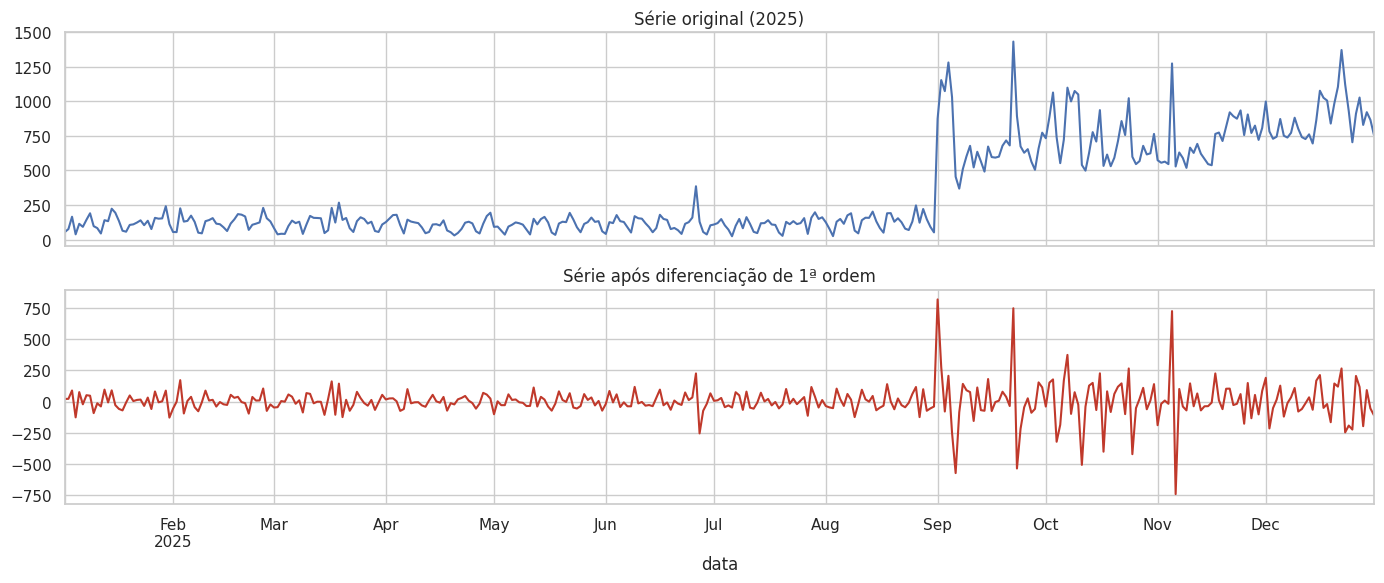

In [ ]:
from statsmodels.tsa.stattools import adfuller, kpss

volume_2025 = df[df['ano'] == 2025].groupby('data').size()
volume_2025.index = pd.to_datetime(volume_2025.index)
serie_2025 = volume_2025.asfreq('D').fillna(0)

serie_diff1 = serie_2025.diff().dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
serie_2025.plot(ax=axes[0], title='Série original (2025)')
serie_diff1.plot(ax=axes[1], title='Série após diferenciação de 1ª ordem', color='#c0392b')
plt.tight_layout()
plt.show()

In [ ]:
adf_stat, adf_p, *_ = adfuller(serie_diff1)
kpss_stat, kpss_p, *_ = kpss(serie_diff1, regression='c', nlags='auto')

print('Após diferenciação de 1ª ordem:')
print(f'  ADF: p-valor={adf_p:.4f} ->', 'estacionária' if adf_p < 0.05 else 'ainda NÃO estacionária')
print(f'  KPSS: p-valor={kpss_p:.4f} ->', 'estacionária' if kpss_p > 0.05 else 'ainda NÃO estacionária')

Após diferenciação de 1ª ordem:
  ADF: p-valor=0.0000 -> estacionária
  KPSS: p-valor=0.1000 -> estacionária


/tmp/ipykernel_555/1838500035.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(serie_diff1, regression='c', nlags='auto')


In [ ]:
# Diferenciação sazonal adicional (lag 7), caso a diferenciação simples não resolva sozinha
serie_diff_sazonal = serie_2025.diff().diff(7).dropna()
adf_stat2, adf_p2, *_ = adfuller(serie_diff_sazonal)
kpss_stat2, kpss_p2, *_ = kpss(serie_diff_sazonal, regression='c', nlags='auto')

print('Após diferenciação de 1ª ordem + diferenciação sazonal (lag 7):')
print(f'  ADF: p-valor={adf_p2:.4f} ->', 'estacionária' if adf_p2 < 0.05 else 'ainda NÃO estacionária')
print(f'  KPSS: p-valor={kpss_p2:.4f} ->', 'estacionária' if kpss_p2 > 0.05 else 'ainda NÃO estacionária')

Após diferenciação de 1ª ordem + diferenciação sazonal (lag 7):
  ADF: p-valor=0.0000 -> estacionária
  KPSS: p-valor=0.1000 -> estacionária


/tmp/ipykernel_555/3387417795.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat2, kpss_p2, *_ = kpss(serie_diff_sazonal, regression='c', nlags='auto')


**Uso direto:** o resultado desta seção define o `d` e o `D` a informar/validar no `pmdarima.auto_arima` (ou a fixar manualmente, caso o Auto-ARIMA não seja usado). Se a diferenciação simples já resolver, `D=0`; se precisar da sazonal também, `D=1`.

## 4. `Grupo designado` a fundo — sinal real ou confundido?

`Grupo designado` teve o maior Cramér's V com `KPI Violado?` (0,114) de toda a EDA anterior, com taxas variando de 0,11% a 8,94% entre equipes. Antes de tratar isso como uma feature "pronta", é preciso descartar duas explicações alternativas:

(a) é só volume — equipes que atendem mais chamados violam mais só por acaso amostral;

(b) é confundido por Prioridade — a equipe com taxa mais alta simplesmente recebe uma fatia maior de chamados de prioridade mais crítica.

In [ ]:
df_kpi = df[df['Entrou para KPI?'] == 'SIM'].copy()

resumo_grupo = df_kpi.groupby('Grupo designado').agg(
    volume_elegivel=('KPI Violado?', 'size'),
    violacoes=('KPI Violado?', lambda s: (s == 'SIM').sum()),
)
resumo_grupo['taxa_violacao_%'] = (resumo_grupo['violacoes'] / resumo_grupo['volume_elegivel'] * 100).round(2)
resumo_grupo = resumo_grupo.sort_values('taxa_violacao_%', ascending=False)
resumo_grupo

,volume_elegivel,violacoes,taxa_violacao_%
Grupo designado,,,
Team06,39,4,10.26
Team07,179,16,8.94
Team08,58,3,5.17
Team03,415,12,2.89
Team09,2058,56,2.72
Team01,41,1,2.44
Team12,395,8,2.03
Team02,251,4,1.59
Team16,152,2,1.32


Correlação (Spearman) entre volume elegível e taxa de violação por grupo: -0.146


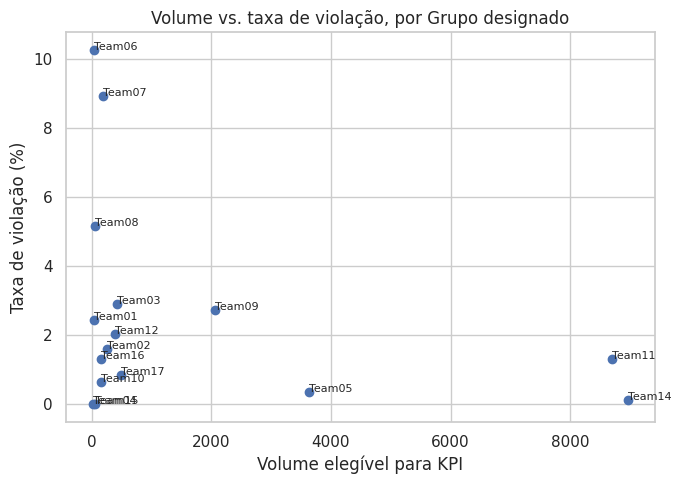

In [ ]:
# (a) Correlação entre volume elegível e taxa de violação por grupo — se for forte e positiva,
# a taxa alta pode ser só efeito de mais oportunidades de violar, não de um problema real da equipe
corr_volume_taxa = resumo_grupo['volume_elegivel'].corr(resumo_grupo['taxa_violacao_%'], method='spearman')
print(f'Correlação (Spearman) entre volume elegível e taxa de violação por grupo: {corr_volume_taxa:.3f}')

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(resumo_grupo['volume_elegivel'], resumo_grupo['taxa_violacao_%'])
for grupo, row in resumo_grupo.iterrows():
    ax.annotate(grupo, (row['volume_elegivel'], row['taxa_violacao_%']), fontsize=8)
ax.set_xlabel('Volume elegível para KPI')
ax.set_ylabel('Taxa de violação (%)')
ax.set_title('Volume vs. taxa de violação, por Grupo designado')
plt.tight_layout()
plt.show()

In [ ]:
# (b) Controle por Prioridade: a diferença entre grupos se mantém DENTRO de cada Prioridade?
tabela_grupo_prioridade_violacao = df_kpi.groupby(['Prioridade', 'Grupo designado'])['KPI Violado?'].apply(
    lambda s: (s == 'SIM').mean() * 100
).unstack()
tabela_grupo_prioridade_violacao.round(2)

Grupo designado,Team01,Team02,Team03,Team04,Team05,Team06,Team07,Team08,Team09,Team10,Team11,Team12,Team14,Team15,Team16,Team17
Prioridade,,,,,,,,,,,,,,,,
2 - Alta,0.00,1.06,2.59,0.0,0.55,0.00,7.41,6.67,2.83,0.00,3.57,1.64,0.07,0.0,6.67,0.00
3 - Média,2.86,1.91,3.28,0.0,0.31,11.11,9.21,0.00,2.67,0.91,1.30,2.20,0.13,0.0,0.73,1.05


## 5. `Status` dentro do universo elegível — o "zero" de associação é real?

A EDA anterior encontrou Cramér's V = 0,000 entre `Status` e `KPI Violado?`. Isso pode ser uma conclusão real (Status realmente não importa) ou um artefato de baixíssima variância de `Status` dentro do subconjunto elegível — se quase todo mundo tem o mesmo Status ali, o teste não tem o que detectar.

In [ ]:
print('Distribuição de Status DENTRO do universo elegível para KPI:')
display(df_kpi['Status'].value_counts())
display(df_kpi['Status'].value_counts(normalize=True).round(4) * 100)

Distribuição de Status DENTRO do universo elegível para KPI:


,count
Status,
Encerrado Automaticamente,15141
Encerrado,10459


,proportion
Status,
Encerrado Automaticamente,59.14
Encerrado,40.86


## 6. Redundância entre texto e variáveis estruturadas

Um único template de texto (*"Problem: Check Application Monitoring"*) responde por 23,4% de toda a base. Antes de assumir que o texto traz sinal incremental relevante para o CatBoost, vale checar se esse template (e os principais outros) já é fortemente previsível a partir de `Grupo designado`/`Categoria` — se for, o ganho marginal do texto pode ser menor do que parece.

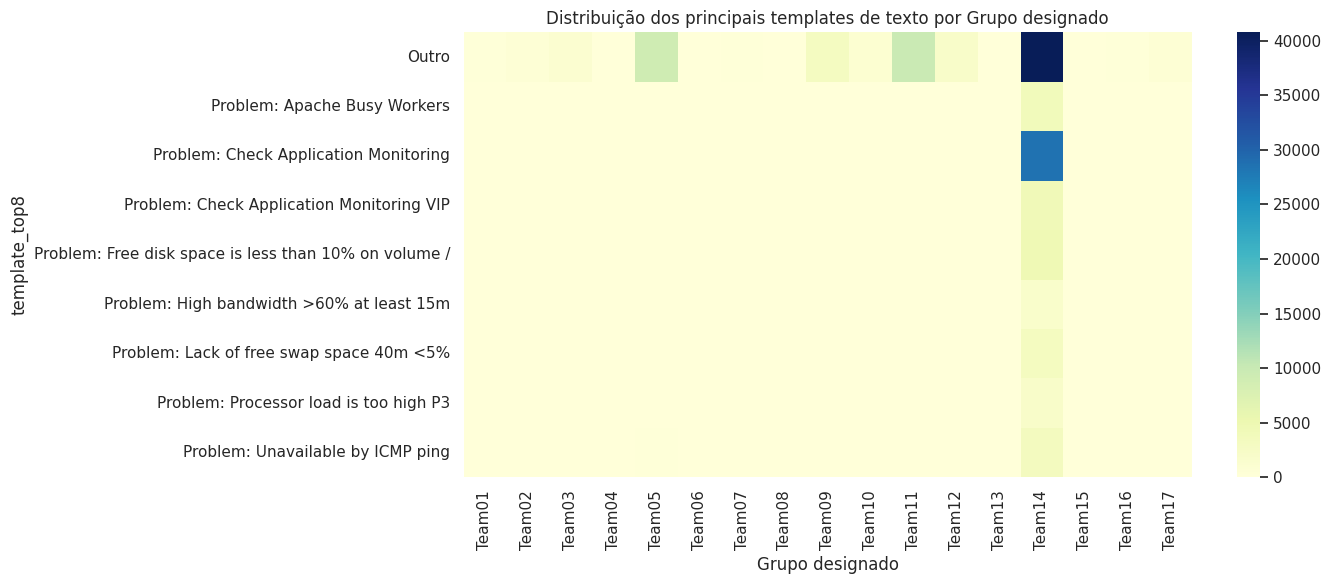

In [ ]:
top_templates = df['Descrição resumida'].value_counts().head(8).index
df['template_top8'] = df['Descrição resumida'].where(df['Descrição resumida'].isin(top_templates), other='Outro')

tabela_template_grupo = pd.crosstab(df['template_top8'], df['Grupo designado'])
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(tabela_template_grupo, cmap='YlGnBu', ax=ax)
ax.set_title('Distribuição dos principais templates de texto por Grupo designado')
plt.tight_layout()
plt.show()

In [ ]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)
    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))

v_template_grupo = cramers_v(df['template_top8'], df['Grupo designado'])
v_template_prioridade = cramers_v(df['template_top8'], df['Prioridade'])
print(f"Cramér's V (template de texto x Grupo designado): {v_template_grupo:.3f}")
print(f"Cramér's V (template de texto x Prioridade): {v_template_prioridade:.3f}")

Cramér's V (template de texto x Grupo designado): 0.174
Cramér's V (template de texto x Prioridade): 0.423


## 7. Caracterização dos outliers extremos de `Duração`

A EDA anterior mostrou um máximo de ~88 milhões de segundos (~1.021 dias) de Duração. Antes de decidir winsorizar ou remover, é preciso caracterizar esse grupo — eles são um padrão sistemático (sempre a mesma Prioridade/Grupo/Status) ou são erros isolados de sistema?

In [ ]:
p99 = df['Duração'].quantile(0.99)
outliers_duracao = df[df['Duração'] > p99].copy()
print(f'Chamados acima do p99 de Duração (> {p99:,.0f}s / {p99/86400:.1f} dias): {len(outliers_duracao)}'.replace(',', '.'))
print()
print('Perfil desses outliers (Status):')
display(outliers_duracao['Status'].value_counts(normalize=True).round(3) * 100)
print()
print('Perfil desses outliers (Prioridade):')
display(outliers_duracao['Prioridade'].value_counts(normalize=True).round(3) * 100)
print()
print('Perfil desses outliers (Aberto por):')
display(outliers_duracao['Aberto por'].value_counts(normalize=True).round(3) * 100)


Chamados acima do p99 de Duração (> 6.157.757s / 71.3 dias): 1226

Perfil desses outliers (Status):


,proportion
Status,
Encerrado Automaticamente,89.6
Encerrado,6.0
Sem Intervenção,4.5



Perfil desses outliers (Prioridade):


,proportion
Prioridade,
3 - Média,84.4
4 - Baixa,15.5
5 - Muito Baixa,0.1



Perfil desses outliers (Aberto por):


,proportion
Aberto por,
Manual,68.9
Monitoramento,31.1


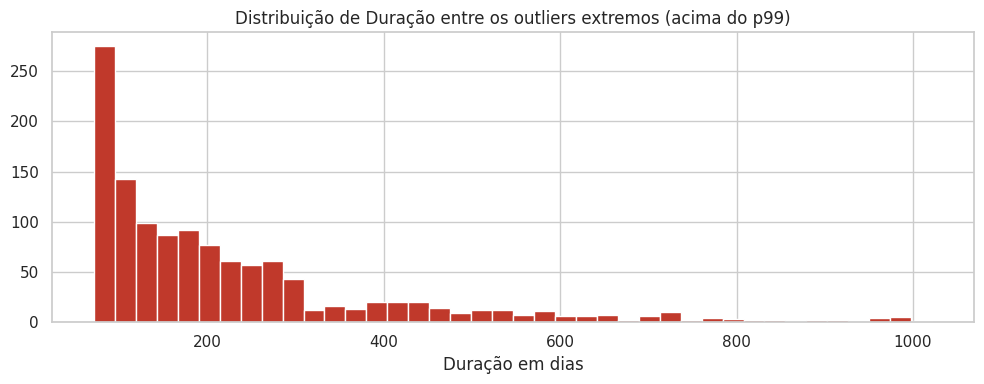

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(outliers_duracao['Duração'] / 86400, bins=40, color='#c0392b')
ax.set_xlabel('Duração em dias')
ax.set_title('Distribuição de Duração entre os outliers extremos (acima do p99)')
plt.tight_layout()
plt.show()


**Decisão:** se os outliers se concentrarem num padrão claro (ex.: quase todos `Encerrado Automaticamente` + `Muito Baixa` + `Monitoramento`), isso reforça a leitura da Seção 2 — são chamados dormentes fechados só por timeout de sistema, não incidentes reais de longa duração. Nesse caso, a decisão correta não é "remover como erro", é **documentar como um comportamento sistêmico do processo de auto-encerramento** e, se `Duração` for usada como feature em algum lugar, aplicar capping (winsorização) ou usar `log1p` sistematicamente.

Possível teoria: comportamento de resolução através de solução definitiva.

## 8. Dispersão do volume semanal de violações — Poisson ou sobre-disperso?

A EDA anterior mostrou uma mediana de 4 violações/semana, variando de 1 a 8. Testar se essa contagem segue aproximadamente uma distribuição Poisson (variância ≈ média) ou é sobre-dispersa (variância >> média) importa para dimensionar corretamente a incerteza esperada em cada fold do walk-forward — eventos raros sobre-dispersos têm mais chance de folds "anômalos".

Média diária de violações: 0.2265
Variância diária: 0.3417
Razão variância/média: 1.51 (>1 indica sobre-dispersão em relação a Poisson)


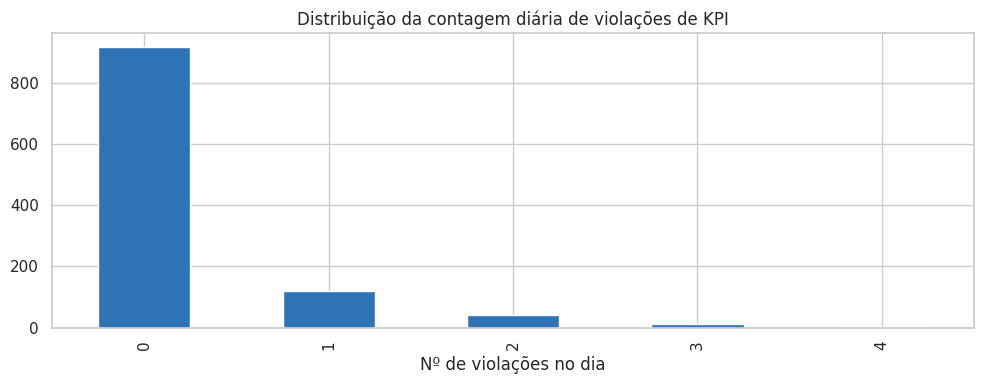

In [ ]:
df_kpi['data'] = df_kpi['Aberto'].dt.date
violacoes_diarias = df_kpi[df_kpi['KPI Violado?'] == 'SIM'].groupby('data').size()

range_completo = pd.date_range(df_kpi['data'].min(), df_kpi['data'].max())
violacoes_diarias = violacoes_diarias.reindex(range_completo.date, fill_value=0)

media = violacoes_diarias.mean()
variancia = violacoes_diarias.var()
razao_dispersao = variancia / media

print(f'Média diária de violações: {media:.4f}')
print(f'Variância diária: {variancia:.4f}')
print(f'Razão variância/média: {razao_dispersao:.2f}', '(>1 indica sobre-dispersão em relação a Poisson)')

fig, ax = plt.subplots(figsize=(10, 4))
violacoes_diarias.value_counts().sort_index().plot(kind='bar', ax=ax, color='#2E74B5')
ax.set_title('Distribuição da contagem diária de violações de KPI')
ax.set_xlabel('Nº de violações no dia')
plt.tight_layout()
plt.show()

**Decisão tomada:** Como a razão variância/média foi maior que 1, o volume de casos positivos por fold do walk-forward será tratado como uma variável de alta incerteza — Dessa forma, também deverá ser reportado o intervalo de confiança por bootstrap.

## 9. Investigação pontual: os 32 casos de `Resolvido > Encerrado`

São poucos casos, mas vale entender se é um padrão sistemático (ex.: sempre no mesmo Grupo, ou sempre com uma diferença de poucos segundos, sugerindo problema de sincronização de relógio) ou erros isolados sem padrão — isso define se tratamos com uma regra (ex.: substituir `Encerrado` por `Resolvido` quando `Resolvido` for posterior) ou removemos os casos.

In [ ]:
casos_incomuns = df[df['Resolvido'].notna() & (df['Resolvido'] > df['Encerrado'])].copy()
casos_incomuns['diferenca_segundos'] = (casos_incomuns['Resolvido'] - casos_incomuns['Encerrado']).dt.total_seconds()

print(f'Total de casos: {len(casos_incomuns)}')
display(casos_incomuns[['Número', 'Prioridade', 'Grupo designado', 'Status', 'Aberto por', 'diferenca_segundos']]
        .sort_values('diferenca_segundos', ascending=False))


Total de casos: 32


,Número,Prioridade,Grupo designado,Status,Aberto por,diferenca_segundos
101462,INC8444768,2 - Alta,Team14,Encerrado,Monitoramento,1899606.0
109574,INC8354945,4 - Baixa,Team14,Encerrado Automaticamente,Monitoramento,432405.0
62737,INC8564684,3 - Média,Team14,Encerrado Automaticamente,Monitoramento,258145.0
62735,INC8564686,3 - Média,Team14,Encerrado Automaticamente,Monitoramento,258144.0
66239,INC8559567,4 - Baixa,Team09,Encerrado Automaticamente,Monitoramento,129353.0
112513,INC8328890,2 - Alta,Team07,Encerrado,Manual,96749.0
90589,INC8524455,2 - Alta,Team09,Encerrado,Manual,85237.0
67551,INC8557728,2 - Alta,Team03,Encerrado,Monitoramento,10615.0
103914,INC8419498,2 - Alta,Team14,Encerrado,Monitoramento,9130.0
103917,INC8419485,2 - Alta,Team14,Encerrado,Monitoramento,9129.0
